# ¿Qué cambió entre la Intercensal 2015 y la 2025?

Las dos encuestas no miden todo igual, así que la API solo compara los indicadores equivalentes y marca cuáles cambiaron de definición. Basta con pedir la entidad (`cve_ent`: 01 a 32, o 00 para el país).

In [1]:
import pandas as pd

yucatan = pd.read_csv("https://eic.datzin.com.mx/api/evolucion?cve_ent=31&formato=csv")
yucatan[["nombre", "valor_2015", "valor_2025", "cambio", "intervalos_se_traslapan", "advertencia"]]

,nombre,valor_2015,valor_2025,cambio,intervalos_se_traslapan,advertencia
0,Porcentaje de población de 12 años y más econó...,52.02,57.44,5.42,False,NaN
1,Porcentaje de población de 12 años y más no ec...,47.79,42.30,-5.49,False,NaN
2,Porcentaje de población de 12 años y más econó...,98.04,98.49,0.45,False,NaN
3,Porcentaje de población de 15 años y más con e...,55.05,43.76,-11.29,False,2025 incluye estudios técnicos o comerciales c...
4,Porcentaje de población de 15 años y más con e...,19.91,24.26,4.35,False,La clasificación de estudios técnicos o comerc...
5,Porcentaje de población de 15 años y más con e...,18.16,24.39,6.23,False,La clasificación de estudios técnicos o comerc...
6,Porcentaje de población de 15 años y más sin i...,6.67,4.77,-1.90,False,2025 cuenta como sin instrucción a quien solo ...
7,Porcentaje de población de 3 años y más que ha...,4.79,3.54,-1.25,False,NaN
8,Porcentaje de población de 3 años y más que ha...,28.89,21.40,-7.49,False,NaN
9,Porcentaje de población que se considera afrom...,0.12,2.07,1.95,False,La pregunta de autoadscripción cambió de redac...


Un cambio es **estadísticamente claro** si los intervalos de confianza de ambos años no se traslapan. Cuando hay `advertencia`, la definición cambió un poco y hay que mencionarlo.

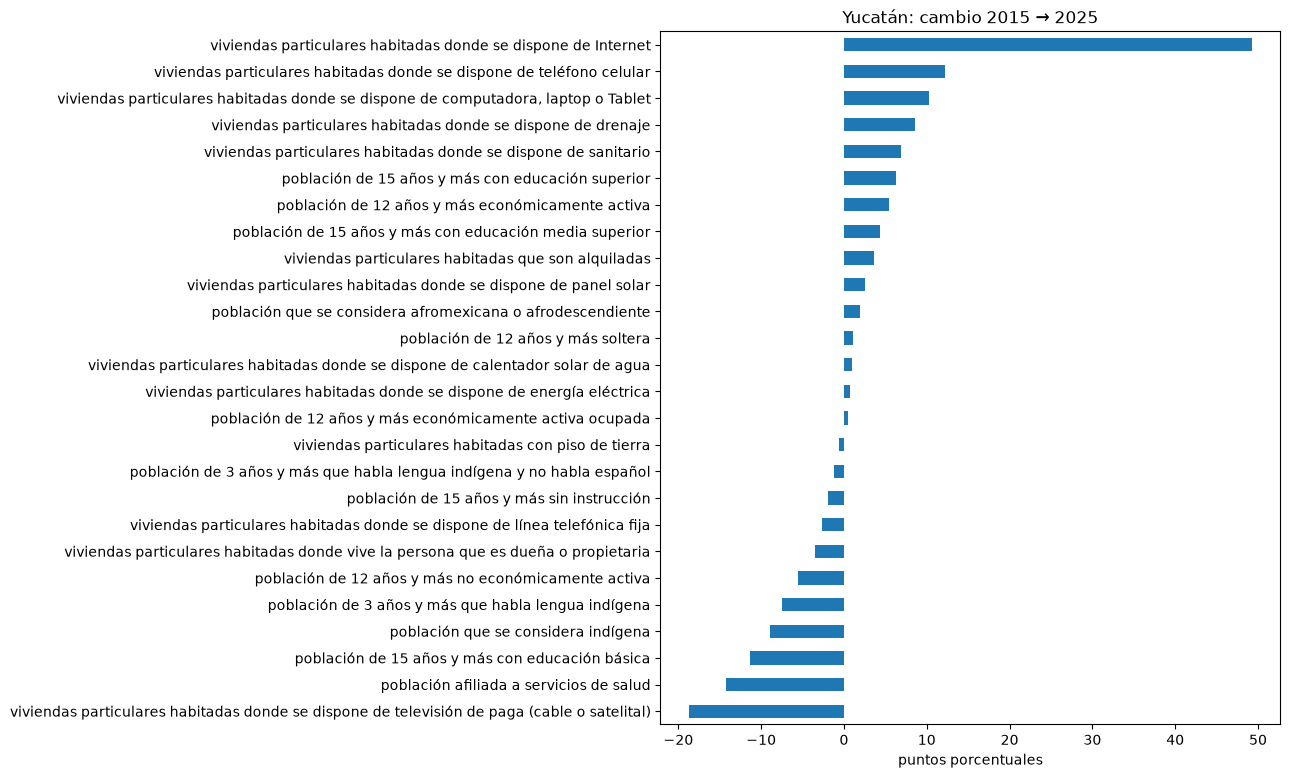

In [2]:
# solo los porcentajes, para que la escala sea comparable (puntos porcentuales)
pct = yucatan[yucatan.nombre.str.startswith("Porcentaje") & ~yucatan.intervalos_se_traslapan]
pct = pct.assign(nombre=pct.nombre.str.replace("Porcentaje de ", "")).sort_values("cambio")
pct.set_index("nombre")["cambio"].plot.barh(figsize=(8, 9), xlabel="puntos porcentuales", ylabel="",
                                            title="Yucatán: cambio 2015 → 2025");

## Lo que no se debe comparar

Algunos indicadores cambiaron tanto de definición que compararlos engaña. Por ejemplo, agua entubada.

In [3]:
equivalencias = pd.read_csv("https://eic.datzin.com.mx/api/equivalencias?formato=csv")
equivalencias[equivalencias.tipo == "no_comparable"][["codigo_2015", "codigo_2025", "nota"]]

,codigo_2015,codigo_2025,nota
4,IND_053,PROM_HNV,Universos distintos: 2015 mide a mujeres de 15...
5,IND_054,PCN_HF,Universos distintos: 2015 mide a mujeres de 15...
10,IND_061,PCN_VPH_AGUADV,2015 cuenta solo agua entubada dentro de la vi...
31,IND_121,PCN_PDER_IMSS,Denominadores distintos: 2015 es porcentaje de...
32,IND_122,PCN_PDER_ISTE,Denominadores distintos: 2015 es porcentaje de...


## El país completo

In [4]:
mexico = pd.read_csv("https://eic.datzin.com.mx/api/evolucion?cve_ent=00&formato=csv")
mexico[["nombre", "valor_2015", "valor_2025", "cambio"]]

,nombre,valor_2015,valor_2025,cambio
0,Porcentaje de población de 12 años y más econó...,5.026000e+01,5.513000e+01,4.87
1,Porcentaje de población de 12 años y más no ec...,4.937000e+01,4.458000e+01,-4.79
2,Porcentaje de población de 12 años y más econó...,9.594000e+01,9.703000e+01,1.09
3,Porcentaje de población de 15 años y más con e...,5.346000e+01,4.535000e+01,-8.11
4,Porcentaje de población de 15 años y más con e...,2.167000e+01,2.584000e+01,4.17
5,Porcentaje de población de 15 años y más con e...,1.863000e+01,2.211000e+01,3.48
6,Porcentaje de población de 15 años y más sin i...,5.830000e+00,4.100000e+00,-1.73
7,Porcentaje de población de 3 años y más que ha...,1.232000e+01,9.830000e+00,-2.49
8,Porcentaje de población de 3 años y más que ha...,6.520000e+00,5.880000e+00,-0.64
9,Porcentaje de población que se considera afrom...,1.160000e+00,1.620000e+00,0.46


---
*Fuente: INEGI, Encuesta Intercensal. Datos: [EIC API + MCP](https://github.com/zamax14/EIC-API-MCP).*